In [1]:
import os
import sys
import json
import warnings
import time

# Add project root to path
sys.path.insert(0, './')

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Core imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats as sp_stats

# Project-specific imports
from main.config_vae import ConfigPoisVAE, ConfigTrainVAE
from main.vae import PoissonVAE
from main.train_vae import TrainerVAE
from base.dataset import make_dataset, make_dataloader
from base.distributions import Poisson
from utils.plotting import set_style, create_figure
from analysis.eval import sparse_score, knn_analysis
from analysis.clf import clf_analysis

# Set plotting style
%matplotlib inline
set_style()

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.1+cu128
CUDA available: True


In [2]:
# Configuration for lin|lin architecture
MODEL_NAME = "poisson_lin_lin_dist1"
DATA_DIR = "Datasets"
DATASET = "vH16"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_DIR = "./checkpoints"

# Model config - linear encoder, linear decoder
PRIOR_CLAMP = -4
PRIOR_LOG_DIST = "uniform"
HARD_FWD = False
EXC_ONLY = False
RMAX_Q = 1.0
N_CH = 32
N_LATENTS = 512
ENC_TYPE = "lin"  # Linear encoder
DEC_TYPE = "lin"  # Linear decoder
ENC_BIAS = False
DEC_BIAS = False
ENC_NORM = False
DEC_NORM = False
FIT_PRIOR = True
ACTIVATION_FN = "swish"
INIT_DIST = "Normal"
INIT_SCALE = 0.0001
RES_EPS = 1.0
USE_BN = False
USE_SE = True
SEED = 0

# Training config
METHOD = "mc"
KL_BETA = 1.0
KL_BETA_MIN = 0.0001
KL_ANNEAL_CYCLES = 0
KL_ANNEAL_PORTION = 0.5
KL_CONST_PORTION = 0.0
LAMBDA_ANNEAL = False
LAMBDA_INIT = 0.0
LAMBDA_NORM = 0.0
TEMP_ANNEAL_PORTION = 0.5
TEMP_ANNEAL_TYPE = "lin"
TEMP_START = 1.0
TEMP_STOP = 0.05
LEARNING_RATE = 0.005
EPOCHS = 3000
BATCH_SIZE = 1000
WARM_RESTART = 0
WARMUP_EPOCHS = 5
OPTIMIZER = "adamax_fast"
OPTIMIZER_KWS = {"weight_decay": 0.0, "betas": [0.9, 0.999], "eps": 1e-08}
SCHEDULER_TYPE = "cosine"
SCHEDULER_KWS = {"T_max": 2995.0, "eta_min": 1e-05}
EMA_RATE = None
GRAD_CLIP = 500
USE_AMP = False
CHKPT_FREQ = EPOCHS  # Save only final checkpoint (set to EPOCHS)
EVAL_FREQ = 20
LOG_FREQ = 10

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Configuration loaded!")
print(f"  Model: {MODEL_NAME}")
print(f"  Device: {DEVICE}")
print(f"  Dataset: {DATASET}")
print(f"  Architecture: {ENC_TYPE}|{DEC_TYPE}")
print(f"  Latent dims: {N_LATENTS}")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")

Configuration loaded!
  Model: poisson_lin_lin_dist1
  Device: cuda
  Dataset: vH16
  Architecture: lin|lin
  Latent dims: 512
  Epochs: 3000
  Batch size: 1000
  Learning rate: 0.005


In [3]:
# Verify CUDA availability and setup
if torch.cuda.is_available():
    print("CUDA is available")
else:
    print("✗ CUDA is NOT available. Training will run on CPU (much slower).")
    print("  Consider installing CUDA toolkit and PyTorch with CUDA support.")

# Set device
device = torch.device(DEVICE)
print(f"\nUsing device: {device}")

CUDA is available

Using device: cuda


In [4]:
# Load dataset
print(f"Loading {DATASET} dataset from {DATA_DIR}...")

trn_data, vld_data, tst_data = make_dataset(
    dataset=DATASET,
    device=device,
    load_dir=DATA_DIR,
)

# Create dataloaders
dl_trn = torch.utils.data.DataLoader(
    trn_data, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    drop_last=True
)
dl_vld = torch.utils.data.DataLoader(
    vld_data, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    drop_last=False
)

print(f"✓ Dataset loaded successfully!")
print(f"  Training samples: {len(trn_data)}")
print(f"  Validation samples: {len(vld_data)}")
print(f"  Training batches: {len(dl_trn)}")
print(f"  Batch size: {BATCH_SIZE}")

Loading vH16 dataset from Datasets...


✓ Dataset loaded successfully!
  Training samples: 80000
  Validation samples: 20000
  Training batches: 80
  Batch size: 1000


In [5]:
# Create model configuration matching reference
# Override base_dir to use simple checkpoint structure
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, MODEL_NAME)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

model_cfg = ConfigPoisVAE(
    prior_clamp=PRIOR_CLAMP,
    prior_log_dist=PRIOR_LOG_DIST,
    hard_fwd=HARD_FWD,
    exc_only=EXC_ONLY,
    rmax_q=RMAX_Q,
    dataset=DATASET,
    n_ch=N_CH,
    n_latents=N_LATENTS,
    enc_type=ENC_TYPE,
    dec_type=DEC_TYPE,
    enc_bias=ENC_BIAS,
    dec_bias=DEC_BIAS,
    enc_norm=ENC_NORM,
    dec_norm=DEC_NORM,
    fit_prior=FIT_PRIOR,
    activation_fn=ACTIVATION_FN,
    init_dist=INIT_DIST,
    init_scale=INIT_SCALE,
    res_eps=RES_EPS,
    use_bn=USE_BN,
    use_se=USE_SE,
    seed=SEED,
    save=False,
    base_dir=CHECKPOINT_DIR,
    data_dir=DATA_DIR,
)

# Override the mods_dir to use simple structure
model_cfg.mods_dir = CHECKPOINT_PATH

print(f"Model Config: {model_cfg.type}")
print(f"  Dataset: {model_cfg.dataset}, size: {model_cfg.input_sz}x{model_cfg.input_sz}")
print(f"  Architecture: {model_cfg.enc_type}|{model_cfg.dec_type}")
print(f"  Latents: {model_cfg.n_latents}, Channels: {model_cfg.n_ch}")
print(f"  Prior clamp: {model_cfg.prior_clamp}")
print(f"  Checkpoint dir: {CHECKPOINT_PATH}")

Model Config: poisson
  Dataset: vH16, size: 16x16
  Architecture: lin|lin
  Latents: 512, Channels: 32
  Prior clamp: -4
  Checkpoint dir: ./checkpoints/poisson_lin_lin_dist1


In [6]:
# Create training configuration matching reference
train_cfg = ConfigTrainVAE(
    method=METHOD,
    kl_beta=KL_BETA,
    kl_beta_min=KL_BETA_MIN,
    kl_anneal_cycles=KL_ANNEAL_CYCLES,
    kl_anneal_portion=KL_ANNEAL_PORTION,
    kl_const_portion=KL_CONST_PORTION,
    lambda_anneal=LAMBDA_ANNEAL,
    lambda_init=LAMBDA_INIT,
    lambda_norm=LAMBDA_NORM,
    temp_anneal_portion=TEMP_ANNEAL_PORTION,
    temp_anneal_type=TEMP_ANNEAL_TYPE,
    temp_start=TEMP_START,
    temp_stop=TEMP_STOP,
    lr=LEARNING_RATE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    warm_restart=WARM_RESTART,
    warmup_epochs=WARMUP_EPOCHS,
    optimizer=OPTIMIZER,
    optimizer_kws=OPTIMIZER_KWS,
    scheduler_type=SCHEDULER_TYPE,
    scheduler_kws=SCHEDULER_KWS,
    ema_rate=EMA_RATE,
    grad_clip=GRAD_CLIP,
    use_amp=USE_AMP,
    chkpt_freq=CHKPT_FREQ,
    eval_freq=EVAL_FREQ,
    log_freq=LOG_FREQ,
)

print(f"Training Config:")
print(f"  Method: {train_cfg.method}")
print(f"  Epochs: {train_cfg.epochs}, Batch size: {train_cfg.batch_size}")
print(f"  LR: {train_cfg.lr}, Optimizer: {train_cfg.optimizer}")
print(f"  Temperature: {train_cfg.temp_start} -> {train_cfg.temp_stop}")
print(f"  KL beta: {train_cfg.kl_beta}")

Training Config:
  Method: mc
  Epochs: 3000, Batch size: 1000
  LR: 0.005, Optimizer: adamax_fast
  Temperature: 1.0 -> 0.05
  KL beta: 1.0


In [7]:
# Initialize the Poisson VAE model
model = PoissonVAE(model_cfg)
model = model.to(device)

# Override the create_chkpt_dir method to use simple directory
def simple_chkpt_dir(self, fit_name=None):
    self.chkpt_dir = CHECKPOINT_PATH
    os.makedirs(self.chkpt_dir, exist_ok=True)

model.create_chkpt_dir = lambda fit_name=None: simple_chkpt_dir(model, fit_name)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model initialized on {device}")
print(f"  Trainable parameters: {n_params:,}")

# Show model architecture summary
print(f"\nModel Architecture:")
print(f"  Encoder output: {model._enc_out_channel()} features")
print(f"  Decoder input: {model._dec_in_channel()} features")
print(f"  Output shape: {model.shape}")

✓ Model initialized on cuda
  Trainable parameters: 262,656

Model Architecture:
  Encoder output: 512 features
  Decoder input: 512 features
  Output shape: (-1, 1, 16, 16)


In [8]:
# Load checkpoint
from pathlib import Path

checkpoint_dir = Path(CHECKPOINT_PATH)
checkpoint_files = sorted(checkpoint_dir.glob("PoissonVAE+TrainerVAE-*.pt"))

if checkpoint_files:
    checkpoint_file = checkpoint_files[-1]  # Load latest
    print(f"Loading checkpoint: {checkpoint_file.name}")
    
    checkpoint = torch.load(checkpoint_file, map_location=device, weights_only=False)
    
    # Handle different checkpoint formats
    if isinstance(checkpoint, dict):
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        elif 'model' in checkpoint:
            model.load_state_dict(checkpoint['model'])
        else:
            model.load_state_dict(checkpoint)
    else:
        model.load_state_dict(checkpoint)
    
    print(f"✓ Checkpoint loaded successfully")
    print(f"  File size: {checkpoint_file.stat().st_size / 1024 / 1024:.1f} MB")
else:
    print(f"⚠ No checkpoint found in {CHECKPOINT_PATH}")

⚠ No checkpoint found in ./checkpoints/poisson_lin_lin_dist1


In [9]:
# Initialize trainer
trainer = TrainerVAE(
    model=model,
    cfg=train_cfg,
    device=device,
    verbose=True,
)

print(f"✓ Trainer initialized")
print(f"  Total iterations: {trainer.n_iters}")
print(f"  Iterations per epoch: {len(trainer.dl_trn)}")


# params: 262.7 K
✓ Trainer initialized
  Total iterations: 240000
  Iterations per epoch: 80


In [10]:
# Train the model
print(f"Starting training...")
print(f"  Architecture: {ENC_TYPE}|{DEC_TYPE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Device: {DEVICE}")
print(f"  Checkpoint dir: {CHECKPOINT_PATH}")
print()

trainer.train(
    epochs=EPOCHS,
    fresh_fit=True,
    save=True
)

print("\n✓ Training completed!")

Starting training...
  Architecture: lin|lin
  Epochs: 3000
  Device: cuda
  Checkpoint dir: ./checkpoints/poisson_lin_lin_dist1



  0%|          | 0/3000 [00:00<?, ?it/s]


TypeError: float() argument must be a string or a real number, not 'NoneType'

In [ ]:
# Checkpoint Cleanup
import os
from pathlib import Path

print("="*80)
print("CHECKPOINT CLEANUP")
print("="*80)

# Remove old checkpoints, keep only the latest
checkpoint_dir = Path(CHECKPOINT_PATH)
if checkpoint_dir.exists():
    checkpoint_files = sorted(checkpoint_dir.glob("PoissonVAE+TrainerVAE-*.pt"))
    
    if len(checkpoint_files) > 1:
        print(f"\nFound {len(checkpoint_files)} checkpoint files")
        print(f"Removing {len(checkpoint_files) - 1} old checkpoints...")
        
        # Keep only the last checkpoint
        for ckpt in checkpoint_files[:-1]:
            ckpt.unlink()
            print(f"  Deleted: {ckpt.name}")
        
        print(f"\n✓ Kept only latest checkpoint: {checkpoint_files[-1].name}")
    else:
        print(f"\n✓ Only one checkpoint found (already clean): {checkpoint_files[0].name if checkpoint_files else 'None'}")
    
    # Show final directory size
    total_size = sum(f.stat().st_size for f in checkpoint_dir.glob("*") if f.is_file())
    print(f"\nCheckpoint directory size: {total_size / 1024 / 1024:.1f} MB")
else:
    print(f"\n⚠ Checkpoint directory not found: {CHECKPOINT_PATH}")

print(f"\n{'='*80}")

CHECKPOINT CLEANUP

✓ Only one checkpoint found (already clean): PoissonVAE+TrainerVAE-3000_(2025_12_27,02:08).pt

Checkpoint directory size: 30.0 MB



TRAINING CURVES
Available metrics: ['grad', 'lr', 't', 'r_max', 'n_exp', 'eval/r2', 'eval/mse', 'eval/kl', 'eval/kl_diag', 'sprs/%-zero', 'sprs/lifetime', 'sprs/population']

Stats organized by epoch (dict format)


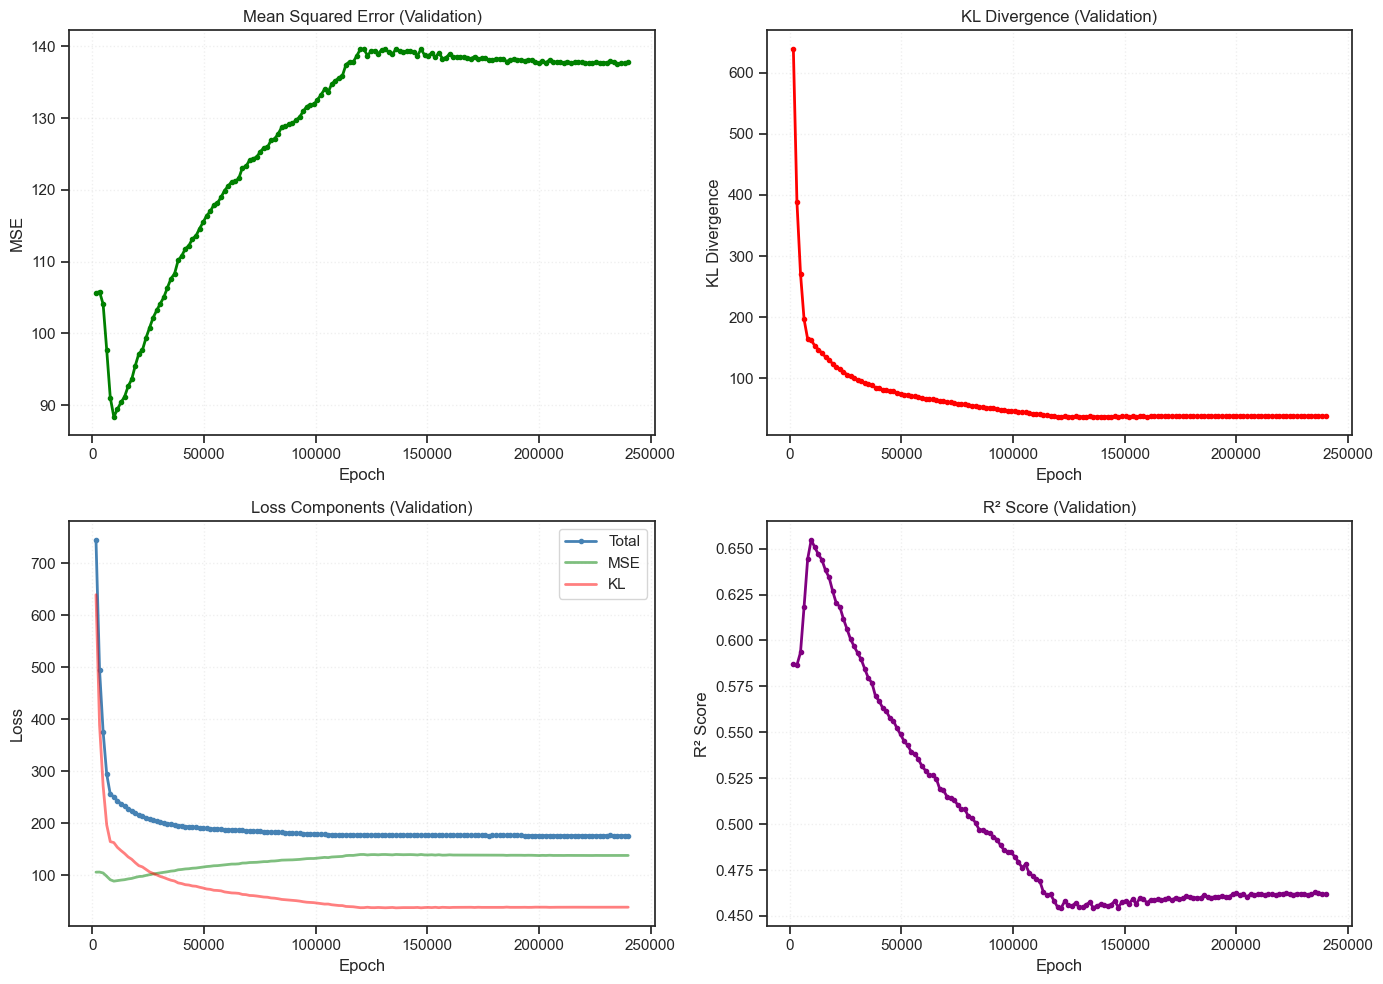


Final Validation Metrics:
  MSE: 137.79
  KL: 38.28
  Total Loss: 176.07



In [ ]:
# Visualize Training Curves
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("TRAINING CURVES")
print("="*80)

# Check if trainer has stats
if hasattr(trainer, 'stats') and len(trainer.stats) > 0:
    stats = trainer.stats
    
    # The stats are organized by metric name
    print(f"Available metrics: {list(stats.keys())}")
    
    # Check the structure of the data
    eval_mse = stats.get('eval/mse', None)
    
    # If the stats contain dict values (organized by epoch)
    if isinstance(eval_mse, dict):
        print("\nStats organized by epoch (dict format)")
        epochs = sorted([int(k) for k in eval_mse.keys() if str(k).isdigit()])
        
        if len(epochs) > 0:
            eval_mse_vals = [eval_mse[e] for e in epochs]
            eval_kl_vals = [stats['eval/kl'].get(e, np.nan) for e in epochs]
            eval_r2_vals = [stats.get('eval/r2', {}).get(e, np.nan) for e in epochs]
            
            # Create figure
            fig, axes = plt.subplots(2, 2, figsize=(14, 10))
            
            axes[0, 0].plot(epochs, eval_mse_vals, linewidth=2, color='green', marker='o', markersize=3)
            axes[0, 0].set_xlabel('Epoch')
            axes[0, 0].set_ylabel('MSE')
            axes[0, 0].set_title('Mean Squared Error (Validation)')
            axes[0, 0].grid(True, alpha=0.3)
            
            axes[0, 1].plot(epochs, eval_kl_vals, linewidth=2, color='red', marker='o', markersize=3)
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('KL Divergence')
            axes[0, 1].set_title('KL Divergence (Validation)')
            axes[0, 1].grid(True, alpha=0.3)
            
            total_loss = np.array(eval_mse_vals) + np.array(eval_kl_vals)
            axes[1, 0].plot(epochs, total_loss, linewidth=2, color='steelblue', marker='o', markersize=3, label='Total')
            axes[1, 0].plot(epochs, eval_mse_vals, linewidth=2, color='green', alpha=0.5, label='MSE')
            axes[1, 0].plot(epochs, eval_kl_vals, linewidth=2, color='red', alpha=0.5, label='KL')
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Loss')
            axes[1, 0].set_title('Loss Components (Validation)')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)
            
            if not all(np.isnan(eval_r2_vals)):
                axes[1, 1].plot(epochs, eval_r2_vals, linewidth=2, color='purple', marker='o', markersize=3)
                axes[1, 1].set_xlabel('Epoch')
                axes[1, 1].set_ylabel('R² Score')
                axes[1, 1].set_title('R² Score (Validation)')
                axes[1, 1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print(f"\nFinal Validation Metrics:")
            print(f"  MSE: {eval_mse_vals[-1]:.2f}")
            print(f"  KL: {eval_kl_vals[-1]:.2f}")
            print(f"  Total Loss: {total_loss[-1]:.2f}")
    
    # Otherwise, check if it's a single value (last value only)
    elif isinstance(eval_mse, (int, float, np.number)):
        print(f"\nStats contain only final values (not time series):")
        print(f"  eval/mse: {eval_mse:.2f}")
        print(f"  eval/kl: {stats.get('eval/kl', 'N/A'):.2f}")
        print(f"  eval/r2: {stats.get('eval/r2', 'N/A')}")
        print("\nNo training curve data available. Only final metrics were stored.")
    
    else:
        print(f"\nUnexpected stats format. Type of eval/mse: {type(eval_mse)}")
        print(f"Value: {eval_mse}")
        
        # Try to read from log file if available
        log_file = os.path.join(CHECKPOINT_PATH, 'TrainerVAE.log')
        if os.path.exists(log_file) and os.path.getsize(log_file) > 0:
            print(f"\nAttempting to parse training log: {log_file}")
            
            # Parse log file for loss values
            epochs_log = []
            losses_log = []
            
            with open(log_file, 'r') as f:
                for line in f:
                    # Look for lines like "epoch # 100, avg loss: 234.567"
                    if 'epoch #' in line and 'avg loss:' in line:
                        try:
                            parts = line.split(',')
                            epoch_str = parts[0].split('#')[1].strip()
                            loss_str = parts[1].split(':')[1].strip()
                            epochs_log.append(int(epoch_str))
                            losses_log.append(float(loss_str))
                        except:
                            continue
            
            if len(epochs_log) > 0:
                print(f"Found {len(epochs_log)} epoch entries in log file")
                
                # Create plot from log data
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                
                axes[0].plot(epochs_log, losses_log, linewidth=2, color='steelblue')
                axes[0].set_xlabel('Epoch')
                axes[0].set_ylabel('Training Loss')
                axes[0].set_title('Training Loss Over Time (from log)')
                axes[0].grid(True, alpha=0.3)
                
                # Last 500 epochs
                n_last = min(500, len(epochs_log))
                axes[1].plot(epochs_log[-n_last:], losses_log[-n_last:], linewidth=2, color='steelblue')
                axes[1].set_xlabel('Epoch')
                axes[1].set_ylabel('Training Loss')
                axes[1].set_title(f'Training Loss (Last {n_last} Epochs)')
                axes[1].grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
                
                print(f"\nTraining Summary (from log):")
                print(f"  Initial loss: {losses_log[0]:.2f}")
                print(f"  Final loss: {losses_log[-1]:.2f}")
                print(f"  Reduction: {losses_log[0] - losses_log[-1]:.2f} ({100*(losses_log[0]-losses_log[-1])/losses_log[0]:.1f}%)")
            else:
                print("Could not parse training curves from log file")
        else:
            print(f"\nLog file not found or empty: {log_file}")
else:
    print("No training statistics found in trainer.stats")

print(f"\n{'='*80}")

POST-TRAINING ANALYSIS

Validation Metrics:
  Negative ELBO: 227.85
  Reconstruction loss: 186.90
  KL divergence: 40.95

Active Neurons (KL > 0.01):
  Active: 505/512
  Proportion: 98.63%

Dead Neuron Detection (Histogram Method):
  Gap threshold: 0.0100
  Dead neurons: 7/512
  Dead proportion: 1.37%

Lifetime Sparsity:
  Overall: 0.7185 (71.85% of samples per neuron on average)
  Min: 0.0110
  Max: 1.0000
  Median: 0.7730


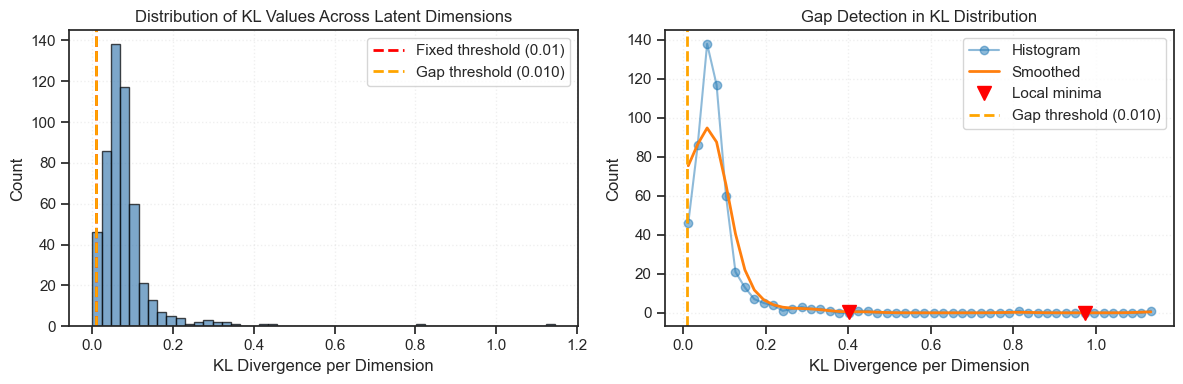

In [ ]:
# Post-Training Analysis
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

print("="*80)
print("POST-TRAINING ANALYSIS")
print("="*80)

# Set model to eval mode and compute validation metrics
model.eval()
with torch.no_grad():
    # Get validation batch
    x_val = next(iter(dl_vld))[0].to(device)
    
    # Forward pass - returns (dist, log_dr, spks, y)
    dist, log_dr, spks, y = model(x_val)
    
    # Compute KL divergence per sample and dimension
    kl_diag = model.loss_kl(log_dr)  # Shape: (batch_size, n_latents)
    
    # Compute metrics
    mse = torch.mean((x_val - y)**2, dim=[1,2,3])
    kl_per_sample = torch.sum(kl_diag, dim=1)
    recon_loss = torch.mean(mse) * (model.cfg.input_sz ** 2)
    kl_loss = torch.mean(kl_per_sample)
    neg_elbo = recon_loss + kl_loss
    
    # Compute KL per latent dimension (average over samples)
    kl_per_dim = torch.mean(kl_diag, dim=0).cpu().numpy()
    
    print(f"\nValidation Metrics:")
    print(f"  Negative ELBO: {neg_elbo.item():.2f}")
    print(f"  Reconstruction loss: {recon_loss.item():.2f}")
    print(f"  KL divergence: {kl_loss.item():.2f}")

# Active neuron analysis
threshold = 0.01
active_mask = kl_per_dim > threshold
n_active = np.sum(active_mask)
n_total = len(kl_per_dim)
active_proportion = n_active / n_total

print(f"\nActive Neurons (KL > {threshold}):")
print(f"  Active: {n_active}/{n_total}")
print(f"  Proportion: {active_proportion:.2%}")

# Dead neuron detection using histogram method
# Bin the KL values and find the gap between small and large values
n_bins = 50
hist, bin_edges = np.histogram(kl_per_dim, bins=n_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Find the gap: look for the largest empty region in the histogram
# First, smooth the histogram slightly
from scipy.ndimage import gaussian_filter1d
smoothed_hist = gaussian_filter1d(hist.astype(float), sigma=1.5)

# Find local minima
from scipy.signal import argrelextrema
minima_idx = argrelextrema(smoothed_hist, np.less)[0]

# Find the minimum closest to zero (in the lower portion)
if len(minima_idx) > 0:
    # Look for minima in the first half of the distribution
    low_minima = minima_idx[bin_centers[minima_idx] < np.median(kl_per_dim)]
    if len(low_minima) > 0:
        gap_idx = low_minima[-1]  # Take the rightmost minimum in the low region
        gap_threshold = bin_centers[gap_idx]
    else:
        gap_threshold = threshold
else:
    gap_threshold = threshold

n_dead_histogram = np.sum(kl_per_dim < gap_threshold)

print(f"\nDead Neuron Detection (Histogram Method):")
print(f"  Gap threshold: {gap_threshold:.4f}")
print(f"  Dead neurons: {n_dead_histogram}/{n_total}")
print(f"  Dead proportion: {n_dead_histogram/n_total:.2%}")

# Compute lifetime sparsity
# Lifetime sparsity is the average proportion of times each neuron is active across the dataset
# A neuron is considered "active" on a sample if its spike count > 0
spks_np = spks.cpu().numpy()  # Shape: (batch_size, n_latents)
active_per_neuron = np.mean(spks_np > 0, axis=0)  # Average over samples
lifetime_sparsity = np.mean(active_per_neuron)  # Average over all neurons

print(f"\nLifetime Sparsity:")
print(f"  Overall: {lifetime_sparsity:.4f} ({lifetime_sparsity*100:.2f}% of samples per neuron on average)")
print(f"  Min: {active_per_neuron.min():.4f}")
print(f"  Max: {active_per_neuron.max():.4f}")
print(f"  Median: {np.median(active_per_neuron):.4f}")

# Plot KL distribution with thresholds
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(kl_per_dim, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Fixed threshold ({threshold})')
axes[0].axvline(gap_threshold, color='orange', linestyle='--', linewidth=2, label=f'Gap threshold ({gap_threshold:.3f})')
axes[0].set_xlabel('KL Divergence per Dimension')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of KL Values Across Latent Dimensions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Smoothed histogram with gap detection
axes[1].plot(bin_centers, hist, 'o-', alpha=0.5, label='Histogram')
axes[1].plot(bin_centers, smoothed_hist, linewidth=2, label='Smoothed')
if len(minima_idx) > 0:
    axes[1].plot(bin_centers[minima_idx], smoothed_hist[minima_idx], 'rv', 
                 markersize=10, label='Local minima')
axes[1].axvline(gap_threshold, color='orange', linestyle='--', linewidth=2, 
                label=f'Gap threshold ({gap_threshold:.3f})')
axes[1].set_xlabel('KL Divergence per Dimension')
axes[1].set_ylabel('Count')
axes[1].set_title('Gap Detection in KL Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")

RECONSTRUCTION VISUALIZATIONS

Reconstructed 32 validation samples
  Mean MSE: 0.7281
  Best MSE: 0.5755
  Worst MSE: 0.8587


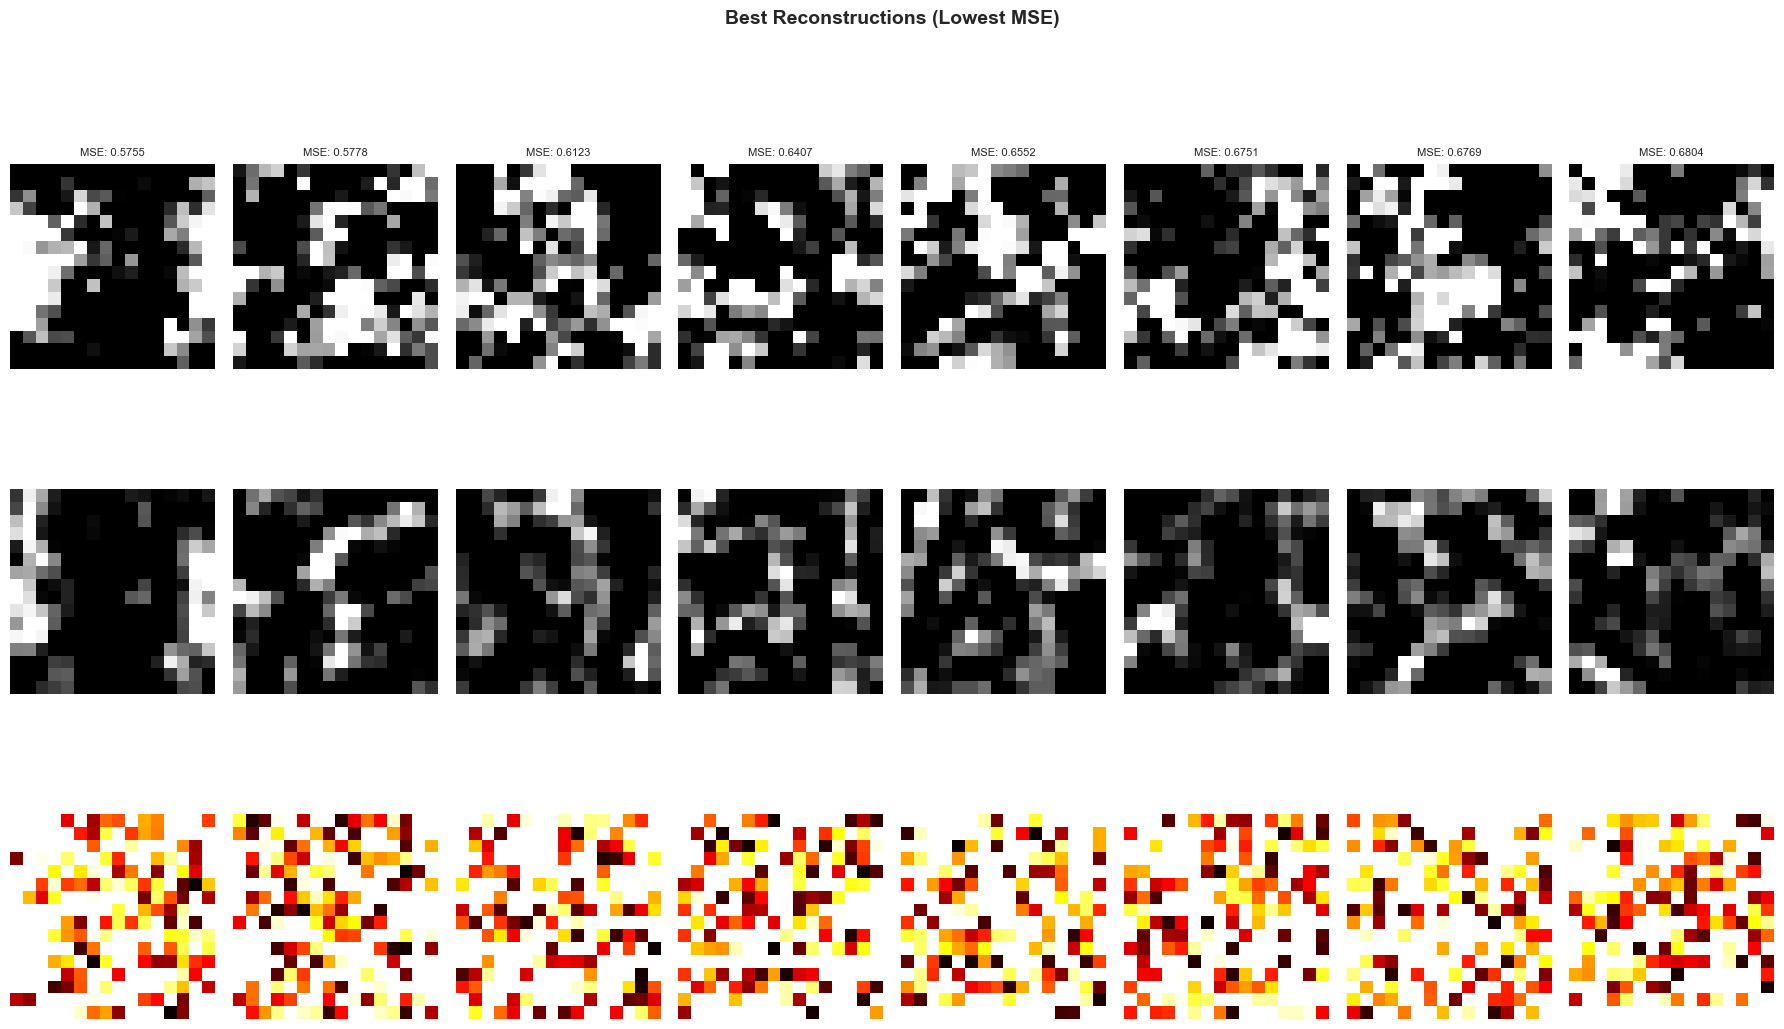

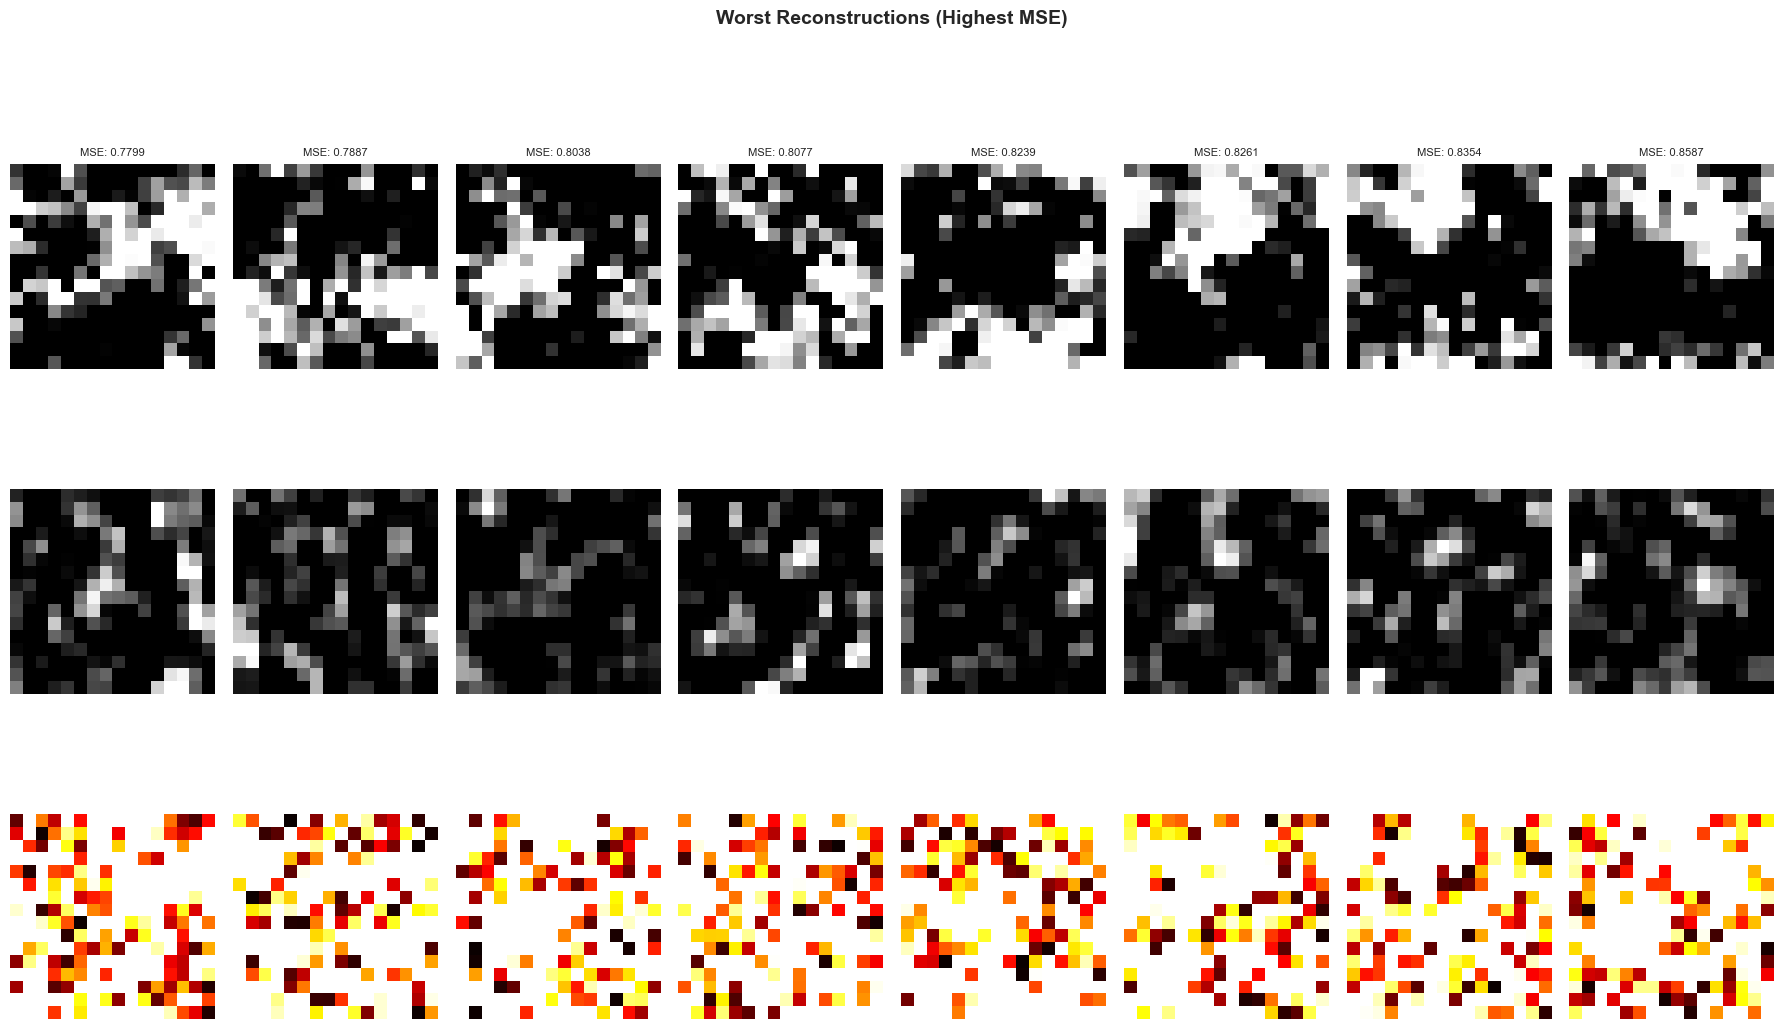

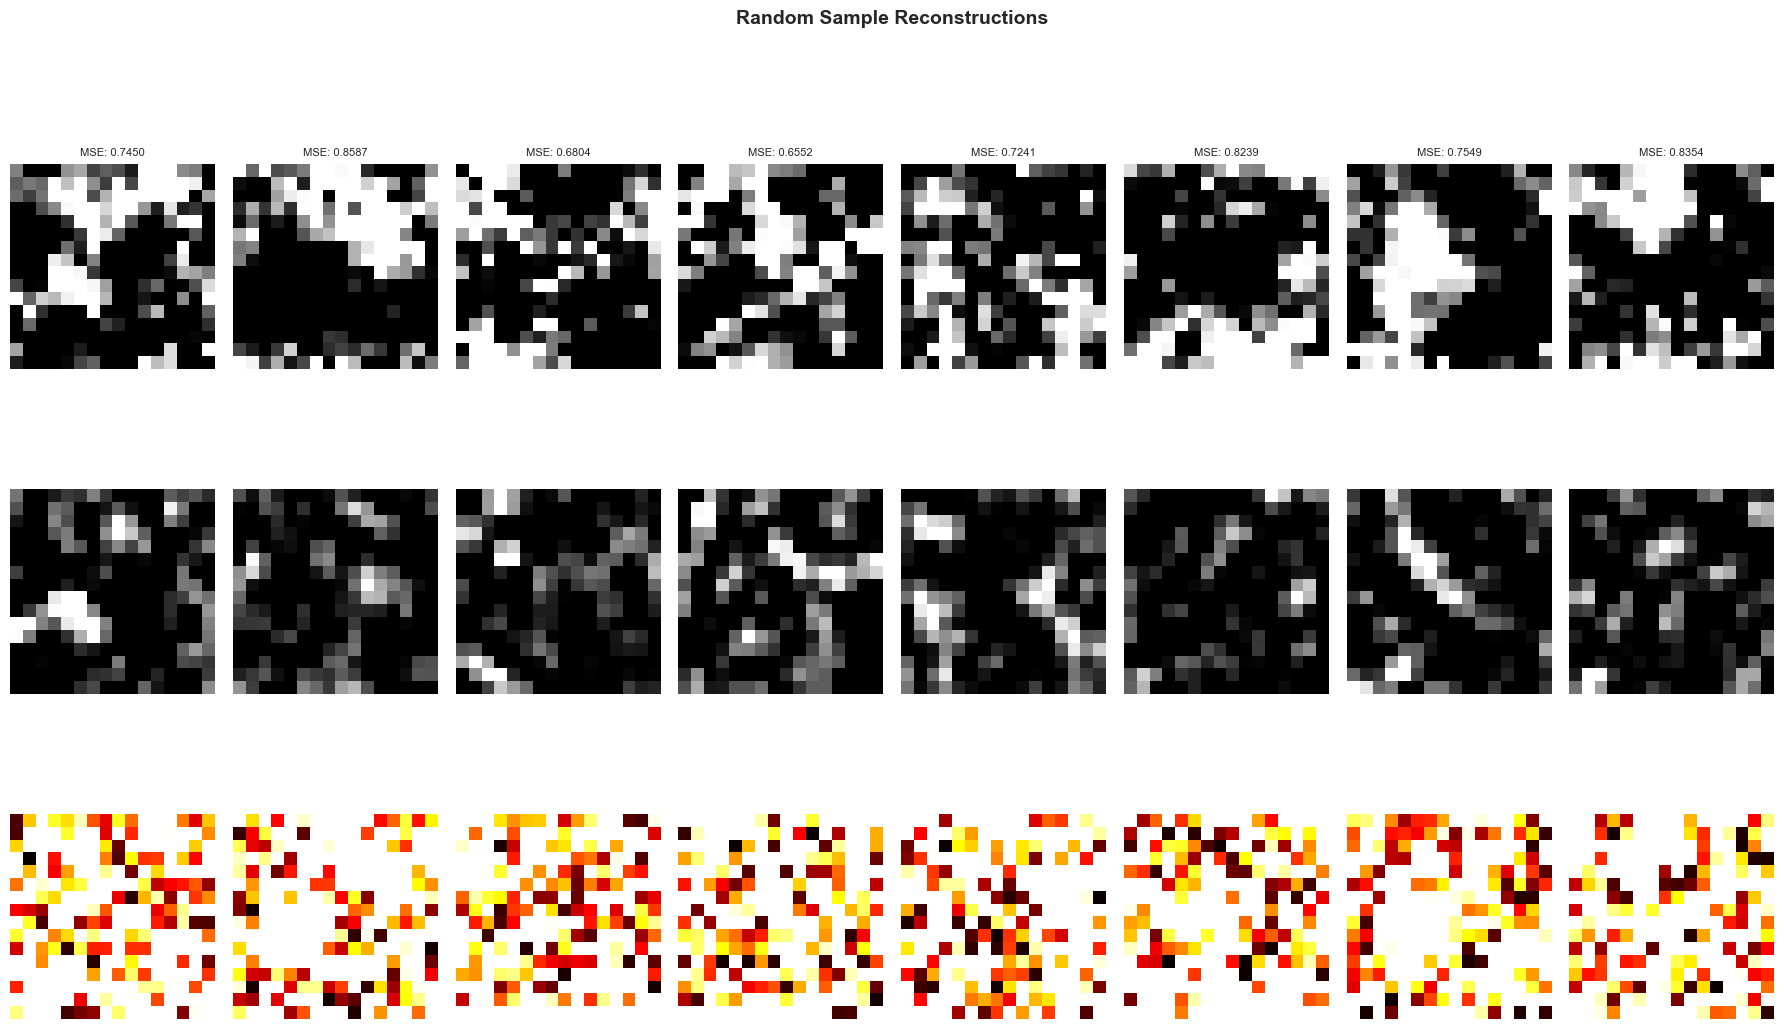


Reconstruction Quality Summary:
  MSE distribution:
    Min: 0.5755
    25th percentile: 0.6892
    Median: 0.7394
    75th percentile: 0.7717
    Max: 0.8587



In [ ]:
# Reconstruction Visualizations
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("RECONSTRUCTION VISUALIZATIONS")
print("="*80)

# Get a batch of validation samples
model.eval()
with torch.no_grad():
    # Sample multiple batches to get variety
    n_samples = 32  # Show 32 examples
    sample_indices = np.random.choice(len(vld_data), n_samples, replace=False)
    
    # Get the samples
    x_samples = torch.stack([vld_data[i][0] for i in sample_indices]).to(device)
    
    # Get reconstructions
    dist, log_dr, spks, y_recon = model(x_samples)
    
    # Move to CPU for visualization
    x_orig = x_samples.cpu().numpy().squeeze()
    y_recon = y_recon.cpu().numpy().squeeze()
    
    # Compute per-sample MSE
    mse_per_sample = np.mean((x_orig - y_recon)**2, axis=(1, 2))
    
    # Sort by reconstruction quality (best and worst)
    sorted_idx = np.argsort(mse_per_sample)
    best_idx = sorted_idx[:8]  # 8 best
    worst_idx = sorted_idx[-8:]  # 8 worst
    
    print(f"\nReconstructed {n_samples} validation samples")
    print(f"  Mean MSE: {np.mean(mse_per_sample):.4f}")
    print(f"  Best MSE: {mse_per_sample[best_idx[0]]:.4f}")
    print(f"  Worst MSE: {mse_per_sample[worst_idx[-1]]:.4f}")
    
    # Create visualization - show original, reconstruction, and difference
    fig = plt.figure(figsize=(18, 12))
    
    # Grid layout: 3 rows (original, reconstruction, difference) x 8 columns
    nrows = 3
    ncols = 8
    
    # Show best reconstructions
    fig.text(0.5, 0.95, 'Best Reconstructions (Lowest MSE)', 
             ha='center', va='top', fontsize=14, fontweight='bold')
    
    for i, idx in enumerate(best_idx):
        # Original
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(x_orig[idx], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'MSE: {mse_per_sample[idx]:.4f}', fontsize=8)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Original', fontsize=10, rotation=0, ha='right', va='center')
        
        # Reconstruction
        ax = plt.subplot(nrows, ncols, ncols + i + 1)
        ax.imshow(y_recon[idx], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Recon', fontsize=10, rotation=0, ha='right', va='center')
        
        # Difference (error map)
        ax = plt.subplot(nrows, ncols, 2*ncols + i + 1)
        diff = np.abs(x_orig[idx] - y_recon[idx])
        im = ax.imshow(diff, cmap='hot', vmin=0, vmax=0.5)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('|Error|', fontsize=10, rotation=0, ha='right', va='center')
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    
    # Show worst reconstructions
    fig = plt.figure(figsize=(18, 12))
    
    fig.text(0.5, 0.95, 'Worst Reconstructions (Highest MSE)', 
             ha='center', va='top', fontsize=14, fontweight='bold')
    
    for i, idx in enumerate(worst_idx):
        # Original
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(x_orig[idx], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'MSE: {mse_per_sample[idx]:.4f}', fontsize=8)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Original', fontsize=10, rotation=0, ha='right', va='center')
        
        # Reconstruction
        ax = plt.subplot(nrows, ncols, ncols + i + 1)
        ax.imshow(y_recon[idx], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Recon', fontsize=10, rotation=0, ha='right', va='center')
        
        # Difference (error map)
        ax = plt.subplot(nrows, ncols, 2*ncols + i + 1)
        diff = np.abs(x_orig[idx] - y_recon[idx])
        im = ax.imshow(diff, cmap='hot', vmin=0, vmax=0.5)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('|Error|', fontsize=10, rotation=0, ha='right', va='center')
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    
    # Show random samples for diversity
    fig = plt.figure(figsize=(18, 12))
    
    fig.text(0.5, 0.95, 'Random Sample Reconstructions', 
             ha='center', va='top', fontsize=14, fontweight='bold')
    
    random_idx = np.random.choice(n_samples, 8, replace=False)
    
    for i, idx in enumerate(random_idx):
        # Original
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(x_orig[idx], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'MSE: {mse_per_sample[idx]:.4f}', fontsize=8)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Original', fontsize=10, rotation=0, ha='right', va='center')
        
        # Reconstruction
        ax = plt.subplot(nrows, ncols, ncols + i + 1)
        ax.imshow(y_recon[idx], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('Recon', fontsize=10, rotation=0, ha='right', va='center')
        
        # Difference (error map)
        ax = plt.subplot(nrows, ncols, 2*ncols + i + 1)
        diff = np.abs(x_orig[idx] - y_recon[idx])
        im = ax.imshow(diff, cmap='hot', vmin=0, vmax=0.5)
        ax.axis('off')
        if i == 0:
            ax.set_ylabel('|Error|', fontsize=10, rotation=0, ha='right', va='center')
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    
    # Summary statistics
    print(f"\nReconstruction Quality Summary:")
    print(f"  MSE distribution:")
    print(f"    Min: {np.min(mse_per_sample):.4f}")
    print(f"    25th percentile: {np.percentile(mse_per_sample, 25):.4f}")
    print(f"    Median: {np.median(mse_per_sample):.4f}")
    print(f"    75th percentile: {np.percentile(mse_per_sample, 75):.4f}")
    print(f"    Max: {np.max(mse_per_sample):.4f}")

print(f"\n{'='*80}")

Decoder Weights:


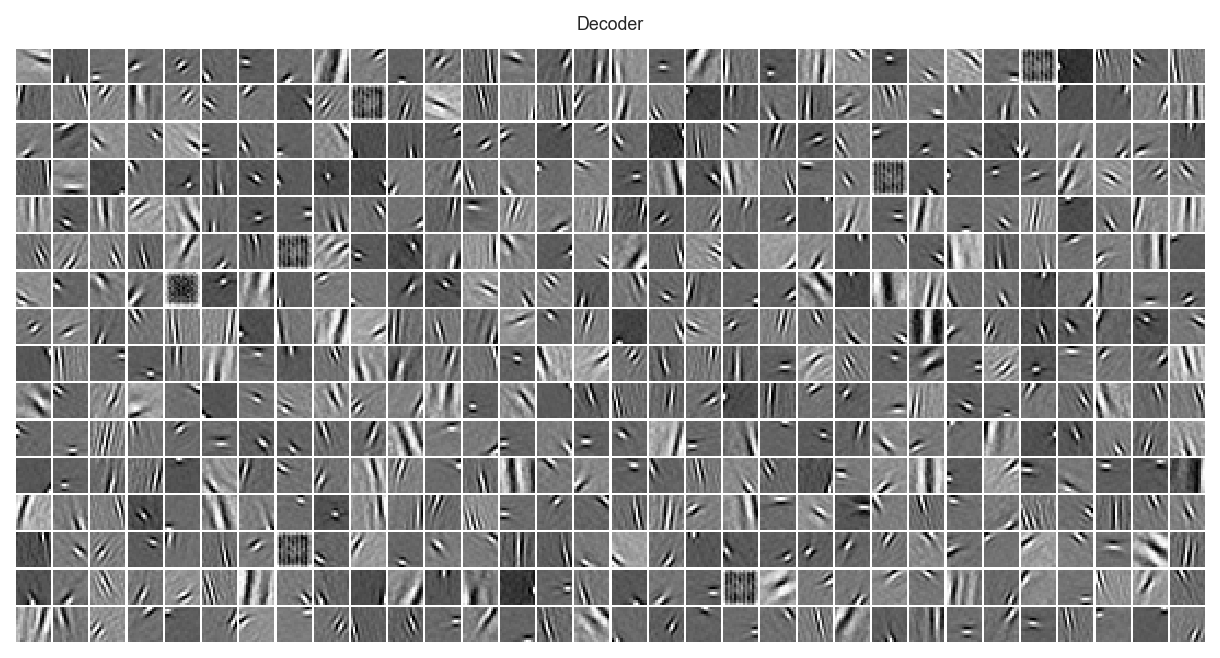


Encoder Weights:


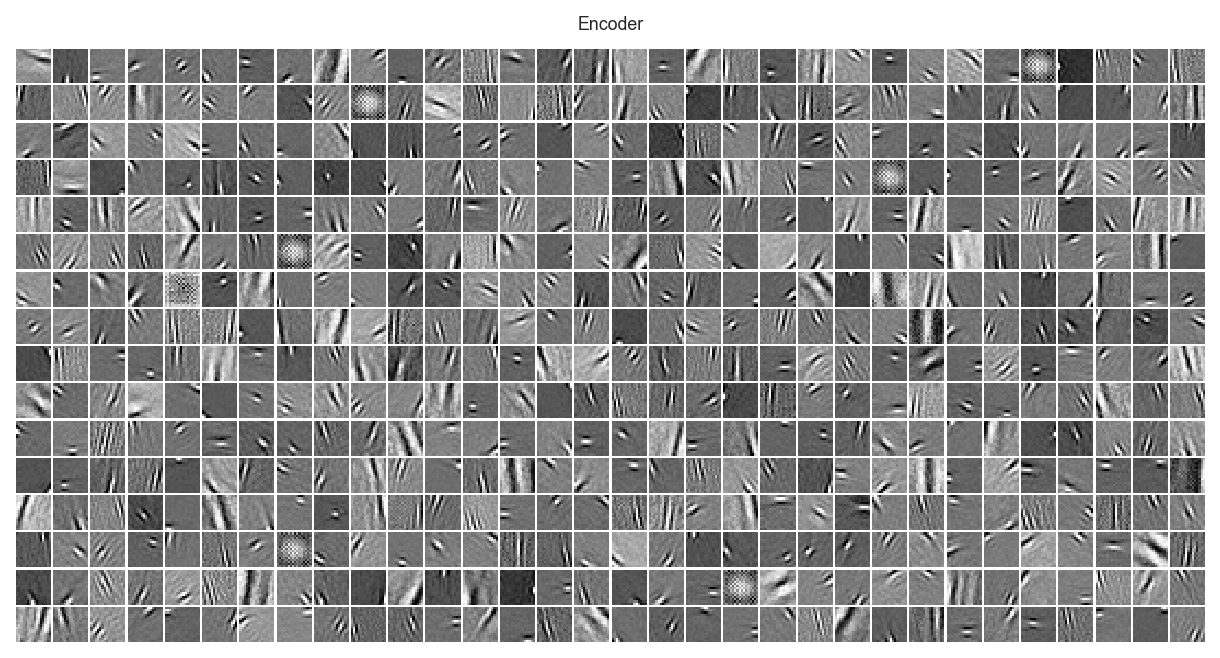

In [ ]:
# Display decoder and encoder weights using model.show()
import matplotlib.pyplot as plt

# Show decoder weights
print("Decoder Weights:")
fig_dec, ax_dec = model.show(which='dec', add_title=True, display=True)
plt.show()

# Show encoder weights
print("\nEncoder Weights:")
fig_enc, ax_enc = model.show(which='enc', add_title=True, display=True)
plt.show()